In [4]:
from sf_workingdir_lilly.dmlab.custom_esn_analysis import get_hidden_states_iso_feat
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import schur

from sf_workingdir_lilly.dmlab.custom_weight_generator import return_weights_for_iso_feat

In [5]:
# define parameters
time_steps = 70
#[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.92, 0.95, 0.97, 0.99]
spectral_radius = [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0] #[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 2, 3, 4, 5, 6, 7, 8]
Hippo_n_feature = 16
Hippo_R = 8
Hippo_L = 64
trial=6
fixed_whh=True
fixed_wih=False

In [ ]:
# schur
spec_rad = 1.3

W_ih, W_hh = return_weights_for_iso_feat(spec_rad, trial, fixed_whh=fixed_whh)
T, Q = schur(W_hh)
print(T)

[[-0.95886636  0.91771895  0.09247637 ...  0.          0.
   0.        ]
 [-0.6752716  -0.95886636  0.13992958 ...  0.          0.
   0.        ]
 [ 0.          0.         -1.1906583  ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ... -0.29988182 -0.1905962
  -0.00942481]
 [ 0.          0.          0.         ...  0.         -0.20857225
   0.10178108]
 [ 0.          0.          0.         ...  0.          0.
  -0.0017386 ]]


In [7]:
print(T.shape)

(1136, 1136)


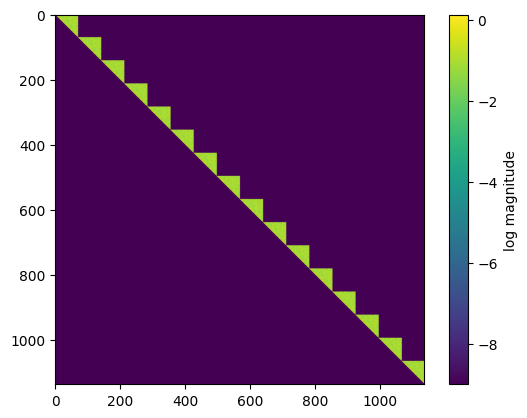

In [11]:
#fig, ax = plt.subplots()
#im = ax.imshow(T)
plt.figure()
plt.imshow(np.log10(np.abs(T) + 1e-9))
plt.colorbar(label='log magnitude')

In [14]:
spec_rad = 1.3

W_ih, W_hh = return_weights_for_iso_feat(spec_rad, trial, fixed_whh=fixed_whh)
T_c, Q_c = schur(W_hh, output='complex')

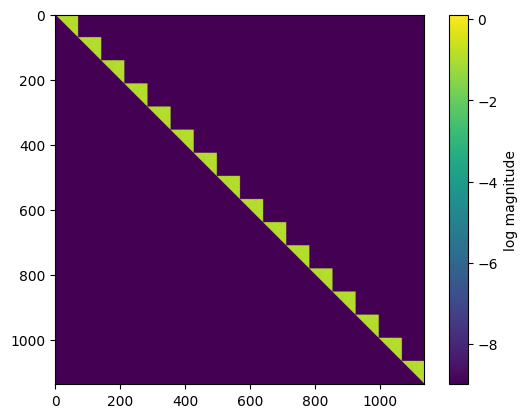

In [15]:
plt.figure()
plt.imshow(np.log10(np.abs(T_c) + 1e-9))
plt.colorbar(label='log magnitude')

In [16]:
# compute just the eigenvalues
eig_vals = np.linalg.eigvals(W_hh)

In [17]:
print(eig_vals)
print(max(eig_vals))

[-0.9588691 +0.7872185j  -0.9588691 -0.7872185j  -1.190659  +0.18886556j
 ... -0.29988176+0.j         -0.2085727 +0.j
 -0.00173852+0.j        ]
(1.2993958+0.039591257j)


In [18]:
eigvals = np.diag(T_c)
r = np.abs(eigvals)
print(r.max(), r.min())

1.3000026 0.0017384104
